In [ ]:
import os
import random
import time
from datetime import date
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_19637_samples.csv" # carbons log-uniform, others uniform
DATA_PATH = "./data/2025-07-22_full_training_data_9844_samples.csv" # carbons log-uniform, others uniform
#datafile = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:

if torch.backends.mps.is_available():
    device = torch.device('mps')  # Mac Metal Performance Shaders
    print(f"Training on device: {device} (Mac GPU)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Training on device: {device} (NVIDIA GPU)")
else:
    device = torch.device('cpu')
    print(f"Training on device: {device} (CPU)")

print(f"PyTorch version: {torch.__version__}")


#device = torch.device("cpu")

Training on device: cuda (NVIDIA GPU)
PyTorch version: 2.5.1+cu121


In [5]:
def print_gpu_memory():
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'Allocated memory: {allocated:.2f} MB')
        print(f'Reserved memory: {reserved:.2f} MB')
    else:
        print("CUDA is not available.")

In [6]:

class AttentionBlock(nn.Module):
    """Multi-head attention block for metabolic modeling with context """
    def __init__(self, d_model=6, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
            # return averaged attention weights
        )
        # c projection to match d_model
        self.Wc_proj = nn.Linear(1, d_model, bias=False)
        # Project back to original c_dim=1
        self.Wc_out = nn.Linear(d_model, 1, bias=False)

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)

        # Normalize and self-attend x
        x_norm = self.layer_norm(x)
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True)
        # attn_out: (B, S, d_model)
        # attn_weights: (B, S, S) averaged over heads

        x_out = attn_out + x

        # Cross-attend concentrations c using same attention weights
        # Project c into d_model space
        c_proj = self.Wc_proj(c)            # (B, S, d_model)
        # Apply attention weights: (B, S, S) @ (B, S, d_model) -> (B, S, d_model)
        # need to batch-matmul with proper dims
        c_att = torch.bmm(attn_weights, c_proj)
        # Project back to scalar per position
        c_out = self.Wc_out(c_att) + c      # (B, S, 1)

        return x_out, c_out


In [7]:
class FeedForwardBlock(nn.Module):

    def __init__(self, d_model, inner_dim_multiplier, dropout=0.1):
        super(FeedForwardBlock, self).__init__()

        self.d_model = d_model + 1
        self.inner_dim = inner_dim_multiplier * (d_model + 1)

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.inner_dim)
        #self.activation = nn.ReLU()
        self.activation = nn.LeakyReLU(0.01)
        self.linear2 = nn.Linear(self.inner_dim, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        #hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerBlock(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=6, n_heads=2, inner_dim_multiplier=5, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, inner_dim_multiplier, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        # Process through attention block
        attn_x, attn_c = self.attention_block(x, c)
        
        # Process through feedforward block
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]  # embeddings portion
        updated_c = ff_output[:, :, -1:]  # context portion
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=6,
        n_heads=2,
        n_layers=4,
        inner_dim_multiplier=5,
        dropout=0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        # Single shared embedding layer
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        # Create transformer blocks
        self.blocks = nn.ModuleList([
            FluxTransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                inner_dim_multiplier=inner_dim_multiplier,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for block in self.blocks:
            x, c = block(x, c)
        
        # Final output is the context vector
        return c

In [10]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    all_columns = inputs + outputs
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, all_columns

In [11]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [12]:
set_seed()

X, y, columns = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 9844 samples from ./data/2025-07-22_full_training_data_9844_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 5906
Test samples: 3938


In [13]:
X_train.size(), y_train.size(), len(columns)

(torch.Size([5906, 115]), torch.Size([5906, 115]), 115)

In [14]:
def train_model(d_model=6, n_heads=2, n_layers=2, inner_dim_multiplier=5, 
               batch_size=128, num_epochs=500, learning_rate=0.001):
    # Create datasets with correct dimensions
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = FluxTransformer(
        vocab_size=115,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        inner_dim_multiplier=inner_dim_multiplier
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    #criterion = nn.HuberLoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    return train_losses, test_losses, model

In [15]:
def plot_loss_curves(train_losses, test_losses, d_model, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Training and Test Loss for d_model = {d_model}", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    plt.show()

In [16]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of actuals"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='Actual')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Concentration")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_flux(
    model,
    X_test,
    y_test,
    columns,
    flux_name: str,
    device: torch.device,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""
    output_cols = columns[20:]
    X_test_ = X_test.unsqueeze(-1)

    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_.to(device))  # shape: [n_samples, 115, 1]
    print("y_pred_tensor.shape:", y_pred_tensor.shape)

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    print("y_pred_full.shape:", y_pred_full.shape,
            "min/max:", y_pred_full.min(), y_pred_full.max())

    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]
    print("y_true_full.shape:", y_true_full.shape,
            "min/max:", y_true_full.min(), y_true_full.max())

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify we have the correct column
    print(f"Flux column index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for biomass
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

Allocated memory: 8.64 MB
Reserved memory: 20.00 MB
Epoch 50/500 | Train Loss: 26.771533 | Test Loss: 24.316435
Epoch 100/500 | Train Loss: 21.584778 | Test Loss: 19.003099
Epoch 150/500 | Train Loss: 19.606681 | Test Loss: 17.470410
Epoch 200/500 | Train Loss: 17.936606 | Test Loss: 16.258943
Epoch 250/500 | Train Loss: 14.827846 | Test Loss: 12.910218
Epoch 300/500 | Train Loss: 13.438449 | Test Loss: 11.488945
Epoch 350/500 | Train Loss: 12.222739 | Test Loss: 10.419171
Epoch 400/500 | Train Loss: 11.359118 | Test Loss: 9.728115
Epoch 450/500 | Train Loss: 10.716802 | Test Loss: 9.151235
Epoch 500/500 | Train Loss: 10.515476 | Test Loss: 8.798488


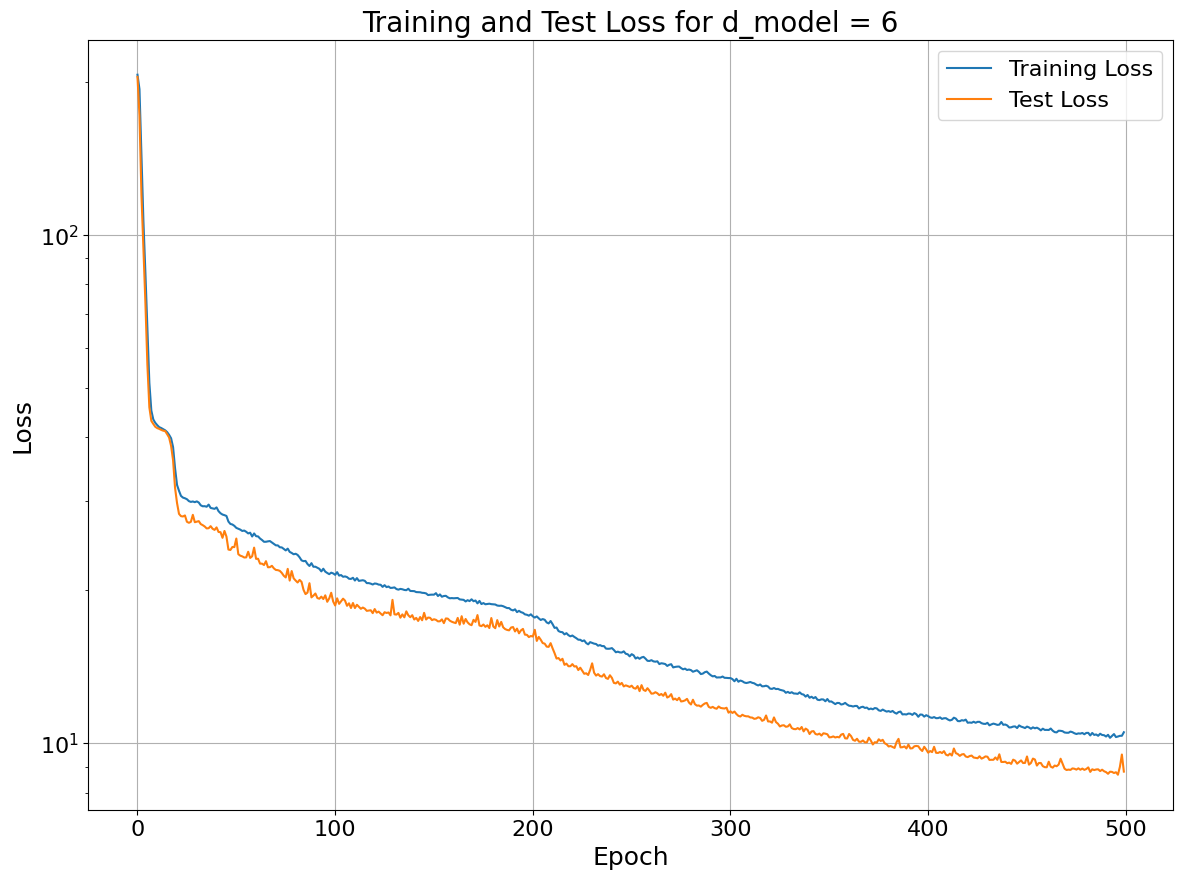

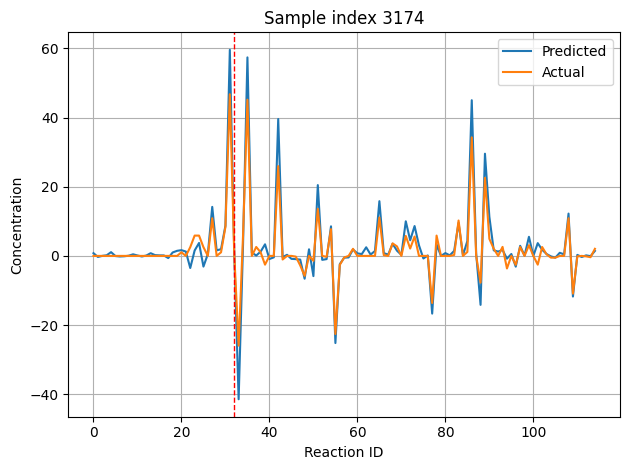

y_pred_tensor.shape: torch.Size([3938, 115, 1])
y_pred_full.shape: (3938, 115) min/max: -62.148823 99.17033
y_true_full.shape: (3938, 115) min/max: -74.93889 109.08469
y_pred_outputs.shape: (3938, 95) min/max: -62.148823 99.17033
y_true_outputs.shape: (3938, 95) min/max: -74.93889 109.08469
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 0.000112493784 to 2.4272914
y_pred_outputs[:, _idx] range: 0.24839973 to 1.2256486


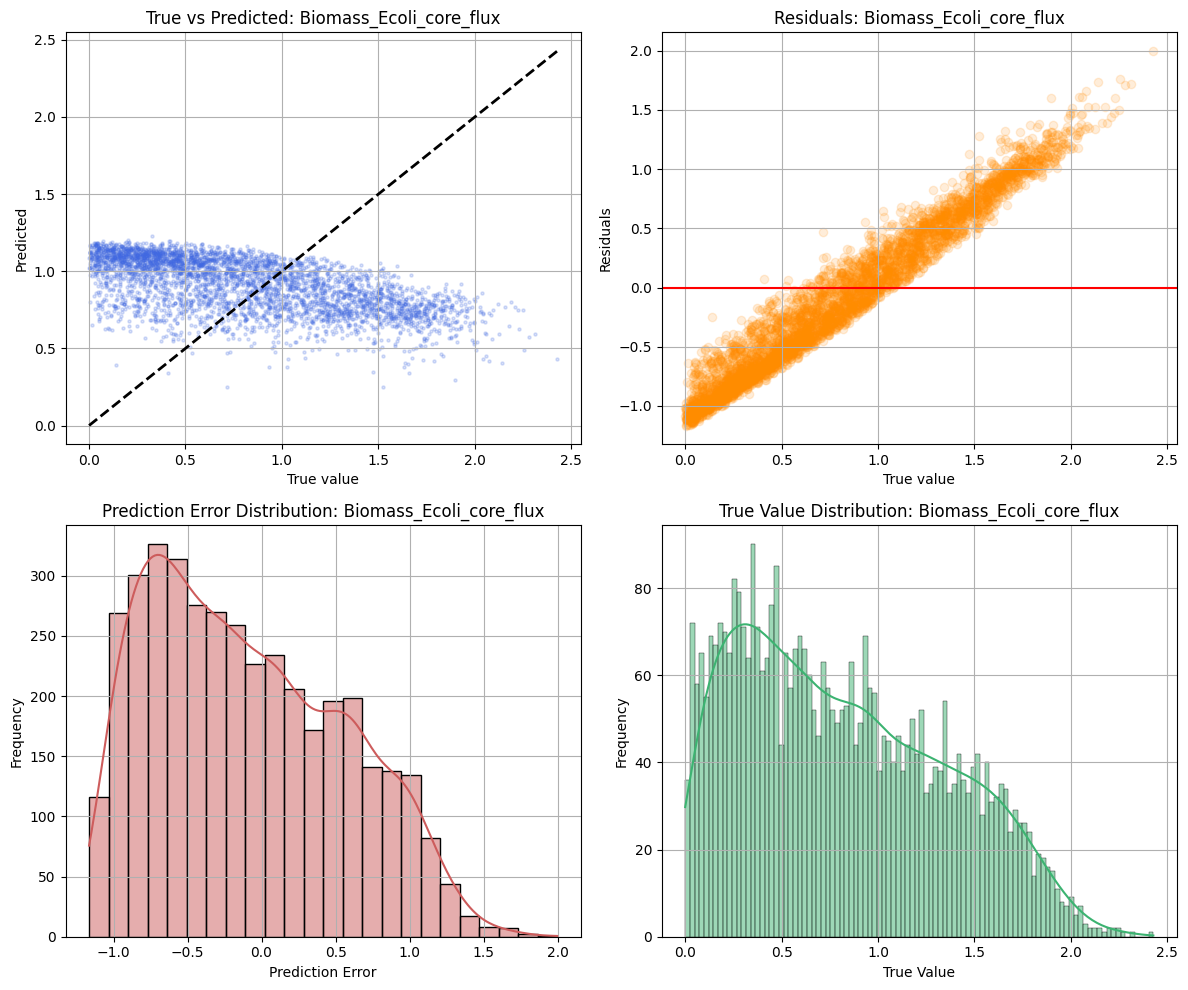

Number of parameters:
2166


In [19]:
print_gpu_memory()

train_losses, test_losses, trained_model = train_model(d_model=6, n_heads=2, n_layers=2, inner_dim_multiplier=5)

plot_loss_curves(train_losses, test_losses, d_model=6)

plot_prediction_sample(X_test, y_test, trained_model)

plot_flux(trained_model, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model.parameters() if p.requires_grad  ))

Epoch 50/500 | Train Loss: 15.871028 | Test Loss: 14.796080
Epoch 100/500 | Train Loss: 10.351833 | Test Loss: 9.737860
Epoch 150/500 | Train Loss: 7.664882 | Test Loss: 6.981528
Epoch 200/500 | Train Loss: 6.370452 | Test Loss: 5.864002
Epoch 250/500 | Train Loss: 6.093706 | Test Loss: 5.076355
Epoch 300/500 | Train Loss: 5.448292 | Test Loss: 4.651342
Epoch 350/500 | Train Loss: 5.190045 | Test Loss: 4.924732
Epoch 400/500 | Train Loss: 4.964823 | Test Loss: 4.502034
Epoch 450/500 | Train Loss: 4.876159 | Test Loss: 4.748165
Epoch 500/500 | Train Loss: 4.750568 | Test Loss: 4.104227


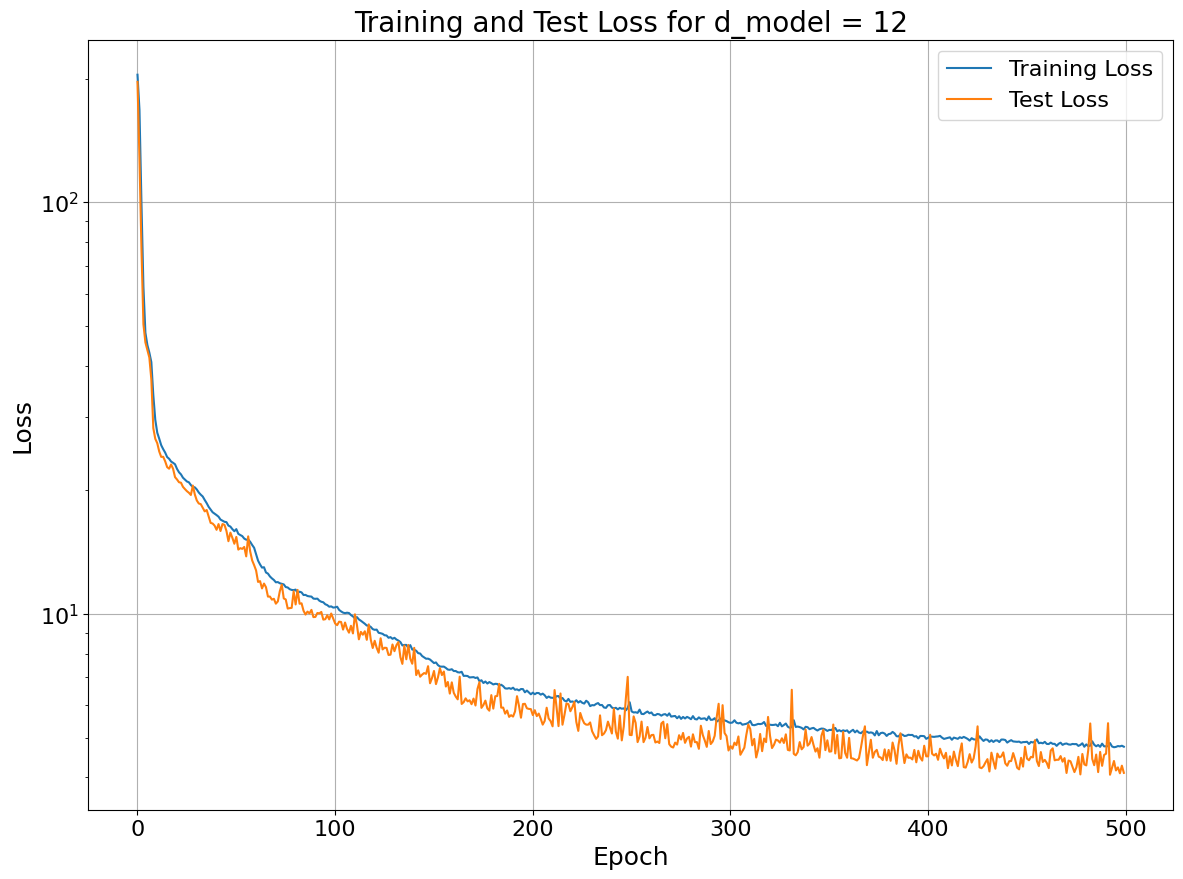

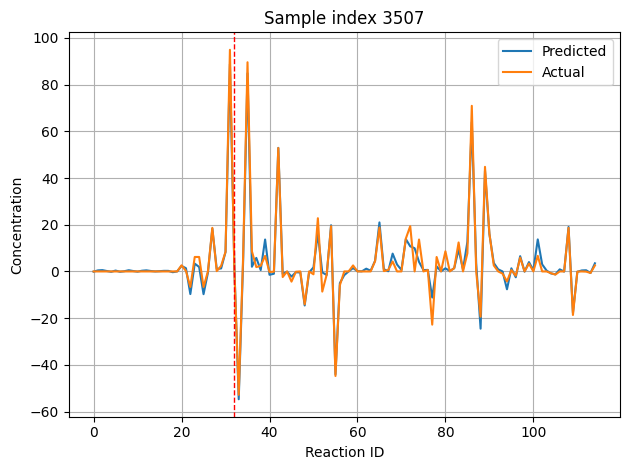

y_pred_tensor.shape: torch.Size([3938, 115, 1])
y_pred_full.shape: (3938, 115) min/max: -64.45012 100.65889
y_true_full.shape: (3938, 115) min/max: -74.93889 109.08469
y_pred_outputs.shape: (3938, 95) min/max: -64.45012 100.65889
y_true_outputs.shape: (3938, 95) min/max: -74.93889 109.08469
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 0.000112493784 to 2.4272914
y_pred_outputs[:, _idx] range: -1.0596421 to 4.264937


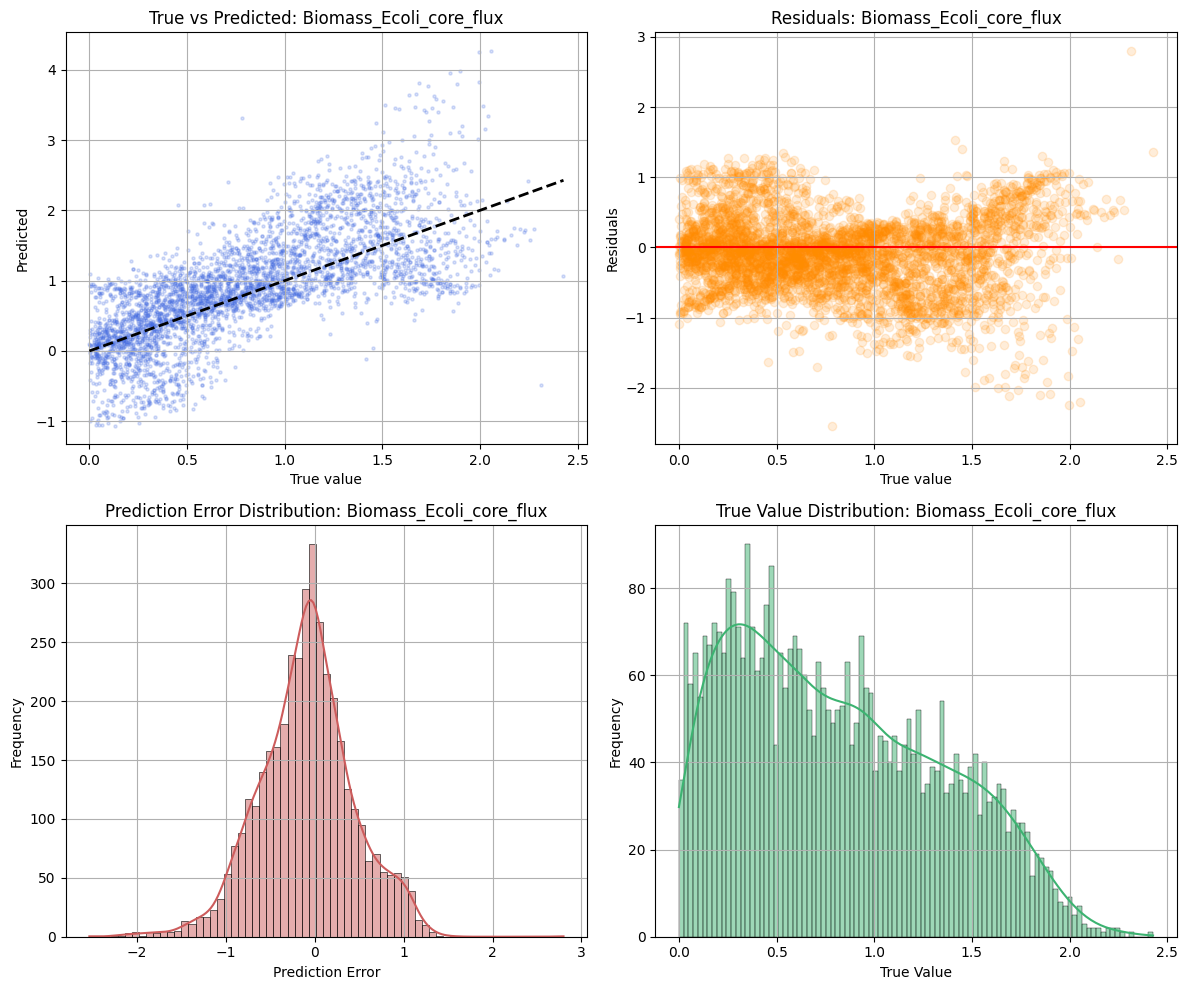

Number of parameters:
6312


In [20]:
train_losses_12_3_2_5, test_losses_12_3_2_5, trained_model_12_3_2_5 = train_model(d_model=12, n_heads=3, n_layers=2, inner_dim_multiplier=5)

plot_loss_curves(train_losses_12_3_2_5, test_losses_12_3_2_5, d_model=12)

plot_prediction_sample(X_test, y_test, trained_model_12_3_2_5)

plot_flux(trained_model_12_3_2_5, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_12_3_2_5.parameters() if p.requires_grad  ))

Epoch 50/500 | Train Loss: 16.275770 | Test Loss: 15.388421
Epoch 100/500 | Train Loss: 9.745649 | Test Loss: 9.152196
Epoch 150/500 | Train Loss: 7.331187 | Test Loss: 6.013550
Epoch 200/500 | Train Loss: 5.805698 | Test Loss: 4.809503
Epoch 250/500 | Train Loss: 5.372598 | Test Loss: 4.270943
Epoch 300/500 | Train Loss: 4.965521 | Test Loss: 4.020400
Epoch 350/500 | Train Loss: 4.669472 | Test Loss: 4.014390
Epoch 400/500 | Train Loss: 4.445198 | Test Loss: 3.941992
Epoch 450/500 | Train Loss: 4.309623 | Test Loss: 3.553396
Epoch 500/500 | Train Loss: 4.157329 | Test Loss: 3.538646


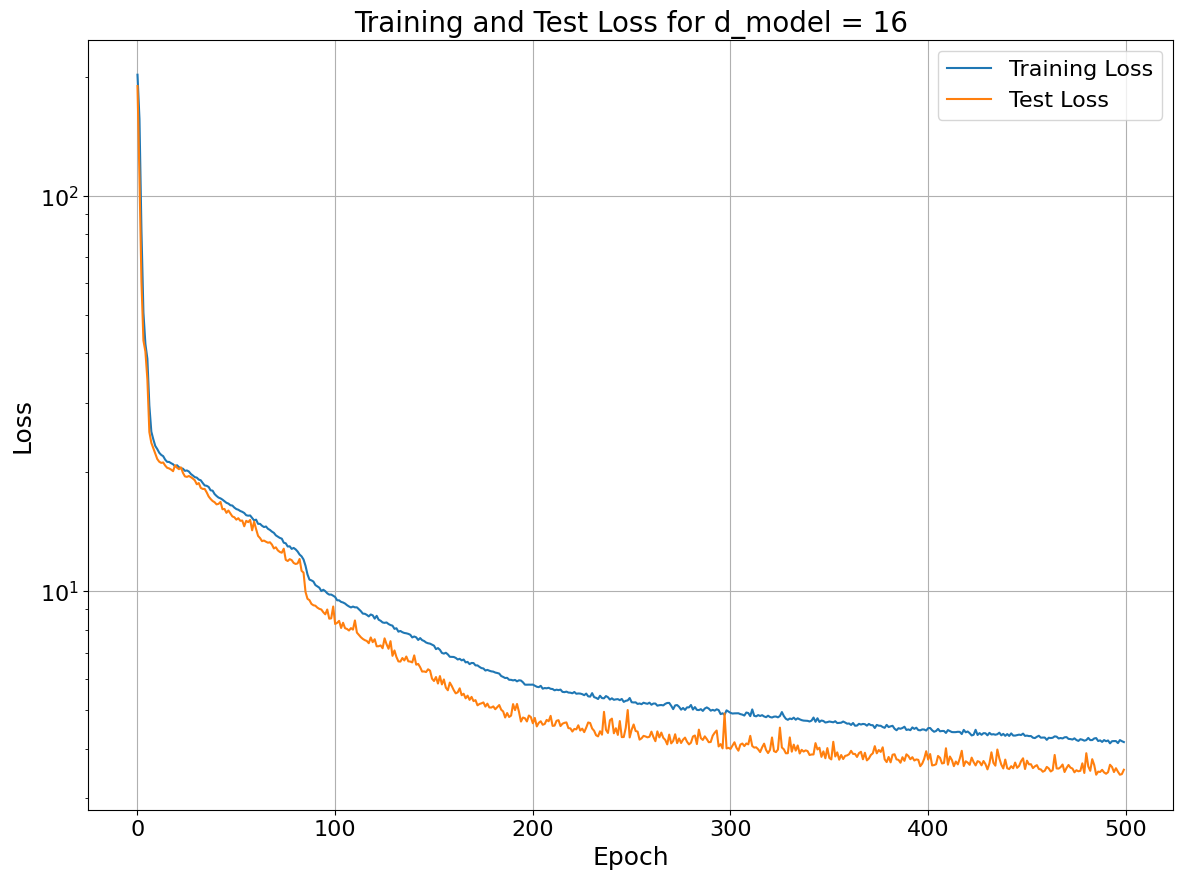

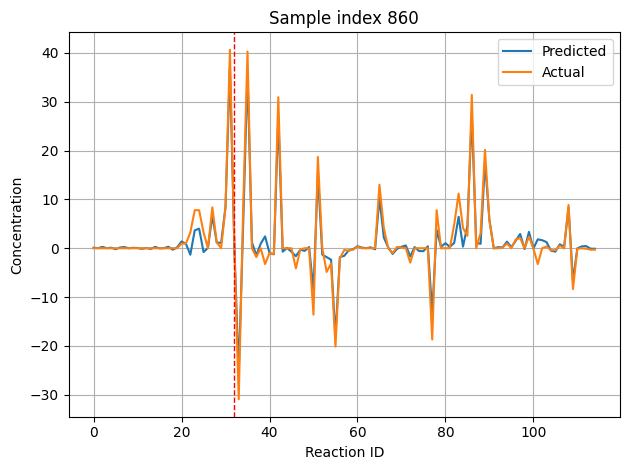

y_pred_tensor.shape: torch.Size([3938, 115, 1])
y_pred_full.shape: (3938, 115) min/max: -70.06098 102.463
y_true_full.shape: (3938, 115) min/max: -74.93889 109.08469
y_pred_outputs.shape: (3938, 95) min/max: -70.06098 102.463
y_true_outputs.shape: (3938, 95) min/max: -74.93889 109.08469
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 0.000112493784 to 2.4272914
y_pred_outputs[:, _idx] range: -1.4035189 to 1.7986102


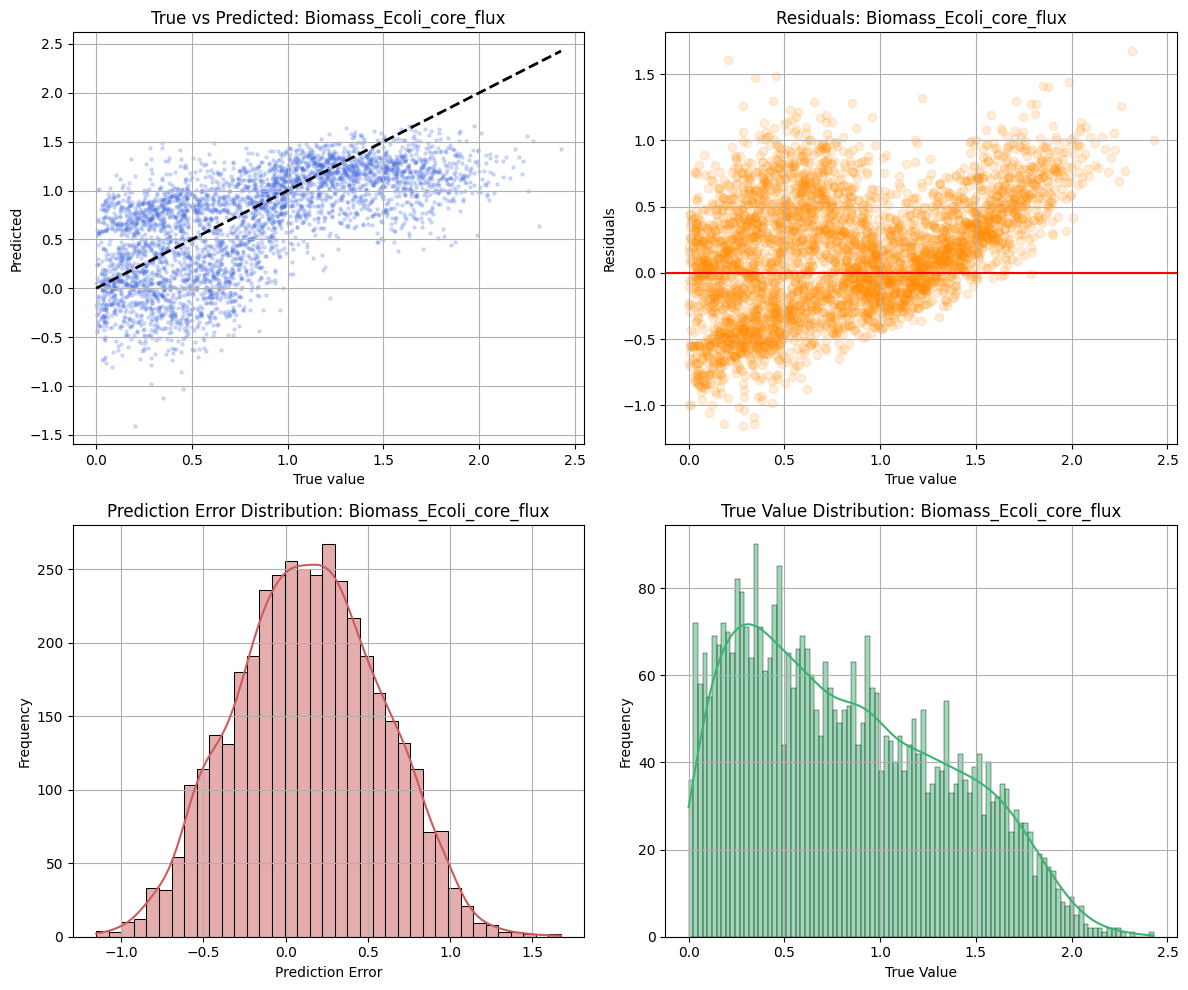

Number of parameters:
9006


In [21]:
train_losses_16_4_2_4, test_losses_16_4_2_4, trained_model_16_4_2_4 = train_model(d_model=16, n_heads=4, n_layers=2, inner_dim_multiplier=4)

plot_loss_curves(train_losses_16_4_2_4, test_losses_16_4_2_4, d_model=16)

plot_prediction_sample(X_test, y_test, trained_model_16_4_2_4)

plot_flux(trained_model_16_4_2_4, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_16_4_2_4.parameters() if p.requires_grad  ))

Epoch 50/500 | Train Loss: 10.654729 | Test Loss: 10.144767
Epoch 100/500 | Train Loss: 5.814737 | Test Loss: 4.836739
Epoch 150/500 | Train Loss: 4.565091 | Test Loss: 3.884967
Epoch 200/500 | Train Loss: 3.984788 | Test Loss: 3.279756
Epoch 250/500 | Train Loss: 3.647413 | Test Loss: 3.102769
Epoch 300/500 | Train Loss: 3.361708 | Test Loss: 2.912810
Epoch 350/500 | Train Loss: 3.188050 | Test Loss: 2.810064
Epoch 400/500 | Train Loss: 3.048018 | Test Loss: 2.612036
Epoch 450/500 | Train Loss: 2.852305 | Test Loss: 2.390126
Epoch 500/500 | Train Loss: 2.767322 | Test Loss: 2.787267


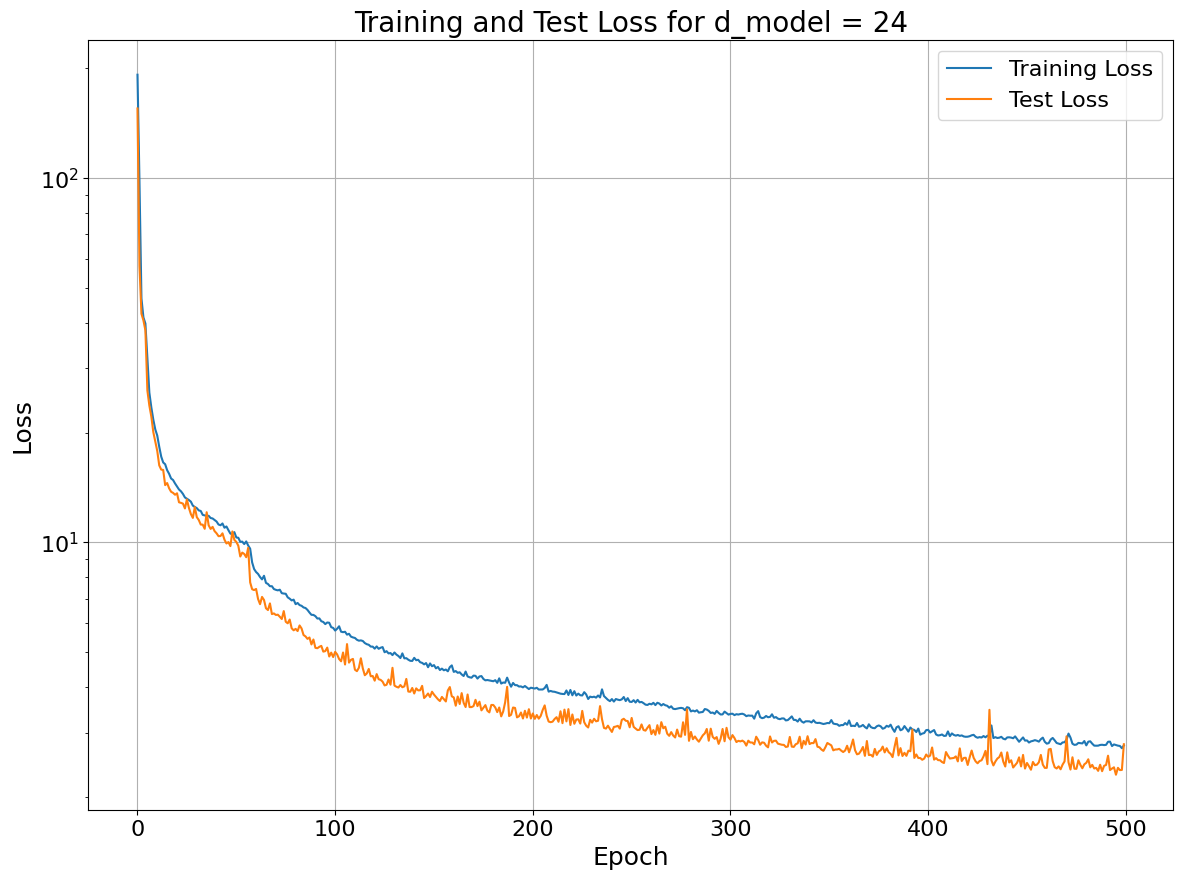

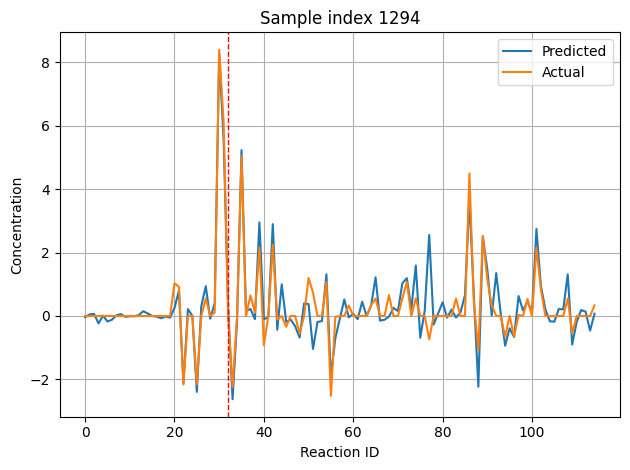

y_pred_tensor.shape: torch.Size([3938, 115, 1])
y_pred_full.shape: (3938, 115) min/max: -68.62402 105.10206
y_true_full.shape: (3938, 115) min/max: -74.93889 109.08469
y_pred_outputs.shape: (3938, 95) min/max: -68.62402 105.10206
y_true_outputs.shape: (3938, 95) min/max: -74.93889 109.08469
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 0.000112493784 to 2.4272914
y_pred_outputs[:, _idx] range: -0.6059774 to 1.9336536


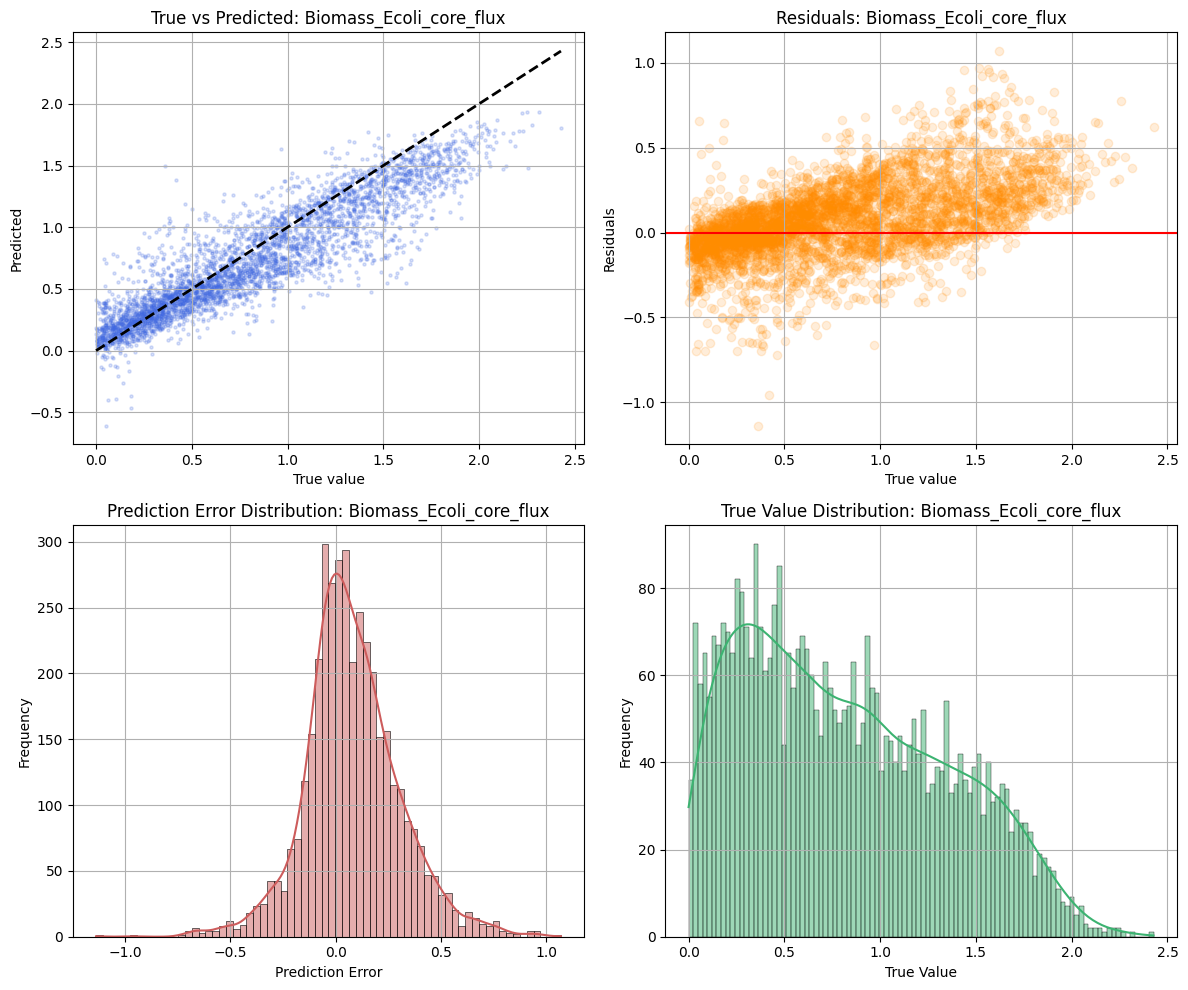

Number of parameters:
23202


In [22]:
train_losses_24_4_2_6, test_losses_24_4_2_6, trained_model_24_4_2_6 = train_model(d_model=24, n_heads=4, n_layers=2, inner_dim_multiplier=6)

plot_loss_curves(train_losses_24_4_2_6, test_losses_24_4_2_6, d_model=24)

plot_prediction_sample(X_test, y_test, trained_model_24_4_2_6)

plot_flux(trained_model_24_4_2_6, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_24_4_2_6.parameters() if p.requires_grad  ))